Task 1: Load and Prepare the Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/drive/MyDrive/data/Training"
test_path = "/content/drive/MyDrive/data/Testing"

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(train_data.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


.



Task 2: Build & Train Model

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1283s 9s/step - accuracy: 0.6846 - loss: 0.7598 - val_accuracy: 0.7652 - val_loss: 0.5054
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 505s 4s/step - accuracy: 0.8480 - loss: 0.4165 - val_accuracy: 0.8366 - val_loss: 0.4138
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 500s 4s/step - accuracy: 0.8908 - loss: 0.3074 - val_accuracy: 0.8955 - val_loss: 0.2855
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 500s 4s/step - accuracy: 0.9239 - loss: 0.2051 - val_accuracy: 0.9062 - val_loss: 0.2501
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 493s 4s/step - accuracy: 0.9375 - loss: 0.1749 - val_accuracy: 0.9107 - val_loss: 0.2528


Task 3: Model Evaluation

In [4]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 362s 7s/step - accuracy: 0.8169 - loss: 1.0537
Test Accuracy: 0.8168749809265137


50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step


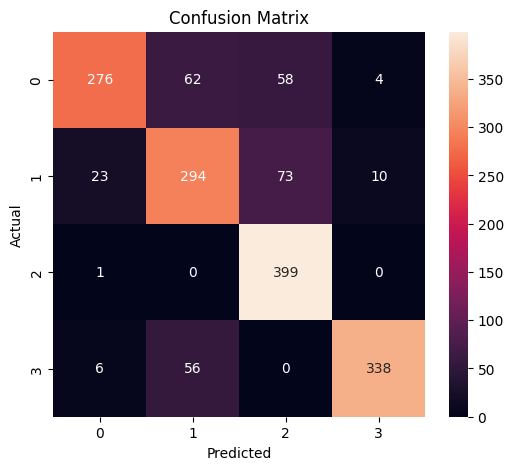

              precision    recall  f1-score   support

      glioma       0.90      0.69      0.78       400
  meningioma       0.71      0.73      0.72       400
     notumor       0.75      1.00      0.86       400
   pituitary       0.96      0.84      0.90       400

    accuracy                           0.82      1600
   macro avg       0.83      0.82      0.82      1600
weighted avg       0.83      0.82      0.82      1600



In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))

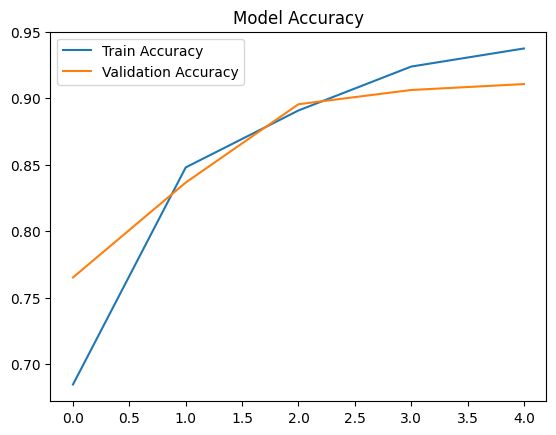

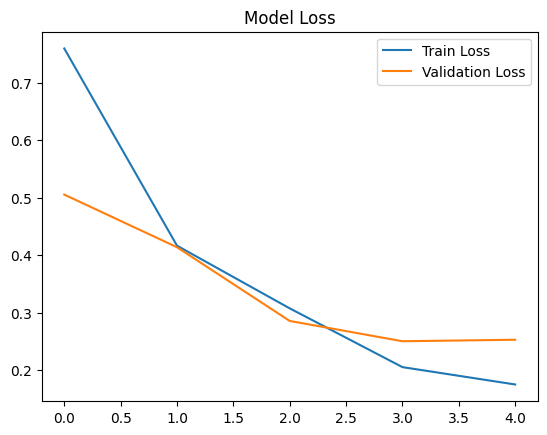

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

Accuracy Graph

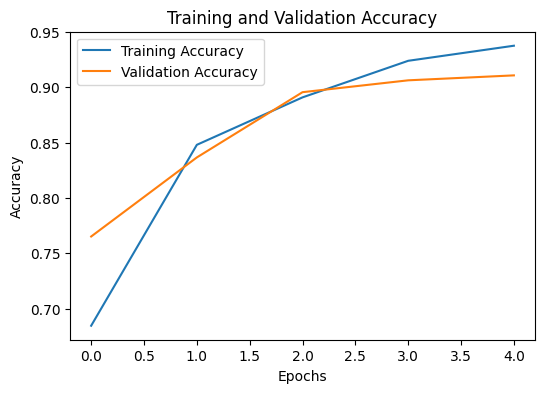

In [8]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()

plt.savefig("accuracy.png", bbox_inches='tight')
plt.show()

Loss Grpah

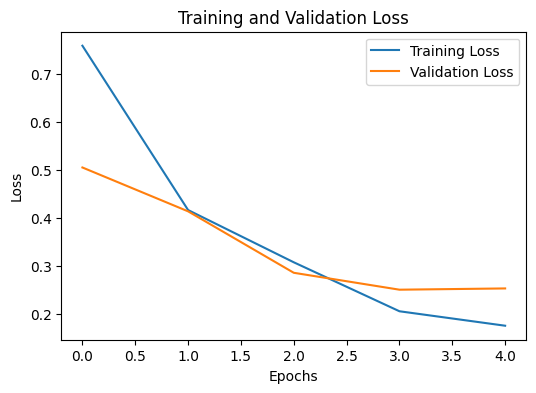

In [9]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()

plt.savefig("loss.png", bbox_inches='tight')
plt.show()

Confusion Matrix

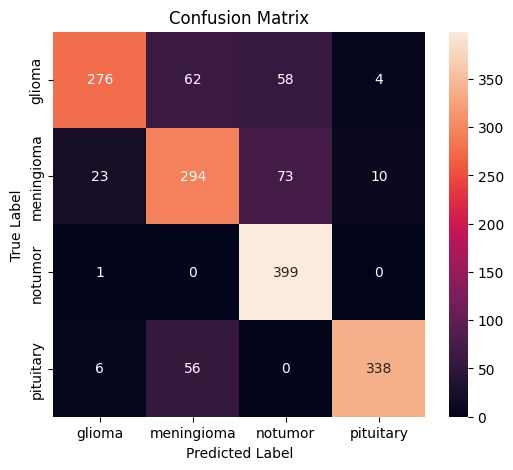

In [10]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=test_data.class_indices.keys(),
    yticklabels=test_data.class_indices.keys()
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.show()